# Importing Libraries

In [127]:
!pip install catboost

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, explained_variance_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn import metrics

pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.float_format = '{:.5f}'.format
np.random.seed(100)

# Load & Inspect Data

In [129]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [130]:
data = pd.concat([train,test],ignore_index=True)
data.shape

(14204, 12)

In [131]:
print(train.shape,test.shape)
print(train.shape[0]+test.shape[0])

(8523, 12) (5681, 11)
14204


In [132]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30000,Low Fat,0.01605,Dairy,249.80920,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.13800
1,DRC01,5.92000,Regular,0.01928,Soft Drinks,48.26920,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42280
2,FDN15,17.50000,Low Fat,0.01676,Meat,141.61800,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27000
3,FDX07,19.20000,Regular,0.00000,Fruits and Vegetables,182.09500,OUT010,1998,NaN,Tier 3,Grocery Store,732.38000
4,NCD19,8.93000,Low Fat,0.00000,Household,53.86140,OUT013,1987,High,Tier 3,Supermarket Type1,994.70520


In [133]:
data.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
14199,FDB58,10.50000,Regular,0.01350,Snack Foods,141.31540,OUT046,1997,Small,Tier 1,Supermarket Type1,NaN
14200,FDD47,7.60000,Regular,0.14299,Starchy Foods,169.14480,OUT018,2009,Medium,Tier 3,Supermarket Type2,NaN
14201,NCO17,10.00000,Low Fat,0.07353,Health and Hygiene,118.74400,OUT045,2002,NaN,Tier 2,Supermarket Type1,NaN
14202,FDJ26,15.30000,Regular,0.00000,Canned,214.62180,OUT017,2007,NaN,Tier 2,Supermarket Type1,NaN
14203,FDU37,9.50000,Regular,0.10472,Canned,79.79600,OUT045,2002,NaN,Tier 2,Supermarket Type1,NaN


# EDA

In [134]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  object 
 1   Item_Weight                11765 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                10188 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.3+ MB


In [135]:
data.describe(include='all')

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
count,14204,11765.00000,14204,14204.00000,14204,14204.00000,14204,14204.00000,10188,14204,14204,8523.00000
unique,1559,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDX13,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT027,NaN,Medium,Tier 3,Supermarket Type1,NaN
freq,10,NaN,8485,NaN,2013,NaN,1559,NaN,4655,5583,9294,NaN
mean,NaN,12.79285,NaN,0.06595,NaN,141.00498,NaN,1997.83068,NaN,NaN,NaN,2181.28891
std,NaN,4.65250,NaN,0.05146,NaN,62.08694,NaN,8.37166,NaN,NaN,NaN,1706.49962
min,NaN,4.55500,NaN,0.00000,NaN,31.29000,NaN,1985.00000,NaN,NaN,NaN,33.29000
25%,NaN,8.71000,NaN,0.02704,NaN,94.01200,NaN,1987.00000,NaN,NaN,NaN,834.24740
50%,NaN,12.60000,NaN,0.05402,NaN,142.24700,NaN,1999.00000,NaN,NaN,NaN,1794.33100
75%,NaN,16.75000,NaN,0.09404,NaN,185.85560,NaN,2004.00000,NaN,NaN,NaN,3101.29640


Lets Look at all the unique values in Columns

In [136]:
#Get Unique values of each columns

for col in data.columns:
    print(f"{col} : Column Summary")

    if data[col].dtype == 'object':
        print(f"Type: Categorical")
        print(f"Unique Values ({data[col].nunique()}): {data[col].unique()}")
    else:
        print(f"Type: Numeric")
        print(f"Number of Unique Values: {data[col].nunique()}")

    print("-" * 50)

Item_Identifier : Column Summary
Type: Categorical
Unique Values (1559): ['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']
--------------------------------------------------
Item_Weight : Column Summary
Type: Numeric
Number of Unique Values: 415
--------------------------------------------------
Item_Fat_Content : Column Summary
Type: Categorical
Unique Values (5): ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
--------------------------------------------------
Item_Visibility : Column Summary
Type: Numeric
Number of Unique Values: 13006
--------------------------------------------------
Item_Type : Column Summary
Type: Categorical
Unique Values (16): ['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']
--------------------------------------------------
Item_MRP : Column Summary
Type: Numeric
Number of Unique Values: 8052
-----

# Finding Missing Values

In [137]:
data.isna().sum()

,0
Item_Identifier,0
Item_Weight,2439
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,4016
Outlet_Location_Type,0


### Note: Imputing Item_weight with mean



In [138]:
data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)

<ipython-input-138-4cade6002097>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Item_Weight'].fillna(data['Item_Weight'].mean(), inplace=True)


In [139]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30000,Low Fat,0.01605,Dairy,249.80920,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.13800
1,DRC01,5.92000,Regular,0.01928,Soft Drinks,48.26920,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42280
2,FDN15,17.50000,Low Fat,0.01676,Meat,141.61800,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27000
3,FDX07,19.20000,Regular,0.00000,Fruits and Vegetables,182.09500,OUT010,1998,NaN,Tier 3,Grocery Store,732.38000
4,NCD19,8.93000,Low Fat,0.00000,Household,53.86140,OUT013,1987,High,Tier 3,Supermarket Type1,994.70520


# Transform Data

In [140]:
data['Item_Visibility'].describe()

,Item_Visibility
count,14204.00000
mean,0.06595
std,0.05146
min,0.00000
25%,0.02704
50%,0.05402
75%,0.09404
max,0.32839


### Removing item-specific bias in visibility. Helps the model understand if an item is more/less visible than usual

In [141]:
# Compute average visibility per item
item_vis_avg = data.groupby('Item_Identifier')['Item_Visibility'].mean()

# Map it to the dataframe
data['Item_visiblity_avg'] = data['Item_Identifier'].map(item_vis_avg)

# Calculate ratio (actual / average)
data['Item_visiblity_avg'] = (data['Item_Visibility'] / data['Item_visiblity_avg']).astype(float)


In [142]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_visiblity_avg
0,FDA15,9.30000,Low Fat,0.01605,Dairy,249.80920,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.13800,0.93108
1,DRC01,5.92000,Regular,0.01928,Soft Drinks,48.26920,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42280,0.93342
2,FDN15,17.50000,Low Fat,0.01676,Meat,141.61800,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27000,0.96007
3,FDX07,19.20000,Regular,0.00000,Fruits and Vegetables,182.09500,OUT010,1998,NaN,Tier 3,Grocery Store,732.38000,0.00000
4,NCD19,8.93000,Low Fat,0.00000,Household,53.86140,OUT013,1987,High,Tier 3,Supermarket Type1,994.70520,0.00000


In [143]:
data.groupby('Item_Type')['Item_Identifier'].unique().reset_index()

,Item_Type,Item_Identifier
0,Baking Goods,"[FDP36, FDW12, FDC37, FDL12, FDN48, FDR12, FDA..."
1,Breads,"[FDO23, FDV11, FDW11, FDR47, FDZ35, FDV59, FDP..."
2,Breakfast,"[FDP49, FDQ49, FDN13, FDN01, FDM25, FDO01, FDM..."
3,Canned,"[FDC14, FDC02, FDL50, FDV49, FDR13, FDI26, FDG..."
4,Dairy,"[FDA15, FDA03, FDU02, FDE51, FDV38, FDM39, FDS..."
5,Frozen Foods,"[FDH17, FDU28, FDR28, FDM40, FDY40, FDC29, FDL..."
6,Fruits and Vegetables,"[FDX07, FDY07, FDX32, FDF32, FDV20, FDA43, FDM..."
7,Hard Drinks,"[DRI11, DRJ59, DRK35, DRG23, DRM47, DRP47, DRQ..."
8,Health and Hygiene,"[NCB42, NCS17, NCX29, NCP05, NCL17, NCI17, NCR..."
9,Household,"[NCD19, NCB30, NCD06, NCP18, NCX54, NCZ18, NCL..."


In [144]:
# Item_identifier 1st 2 character's are common and other characters describes about the product

data['Item_Type_Combined'] = data['Item_Identifier'].apply(lambda x: x[0:2])
data['Item_Type_Combined'].value_counts()

,count
Item_Type_Combined,
FD,10201
NC,2686
DR,1317


In [145]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_visiblity_avg,Item_Type_Combined
0,FDA15,9.30000,Low Fat,0.01605,Dairy,249.80920,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.13800,0.93108,FD
1,DRC01,5.92000,Regular,0.01928,Soft Drinks,48.26920,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42280,0.93342,DR
2,FDN15,17.50000,Low Fat,0.01676,Meat,141.61800,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27000,0.96007,FD
3,FDX07,19.20000,Regular,0.00000,Fruits and Vegetables,182.09500,OUT010,1998,NaN,Tier 3,Grocery Store,732.38000,0.00000,FD
4,NCD19,8.93000,Low Fat,0.00000,Household,53.86140,OUT013,1987,High,Tier 3,Supermarket Type1,994.70520,0.00000,NC


In [146]:
data.pivot_table(values="Item_Outlet_Sales",index=['Item_Type_Combined','Item_Type'],aggfunc='sum')

Item_Outlet_Sales
Item_Type_Combined Item_Type                               
DR                 Dairy                       245178.18680
                   Hard Drinks                 457793.42720
                   Soft Drinks                 892897.72200
FD                 Baking Goods               1265525.34220
                   Breads                      553237.18880
                   Breakfast                   232298.95160
                   Canned                     1444151.49260
                   Dairy                      1277415.86440
                   Frozen Foods               1825734.78860
                   Fruits and Vegetables      2820059.81680
                   Meat                        917565.61200
                   Seafood                     148868.21940
                   Snack Foods                2732786.08700
                   Starchy Foods               351401.25040
NC                 Health and Hygiene         1045200.13780
                   Household                  2055493.71320
                   Others                      325517.60960

In [147]:
data['Item_Type_Combined'] = data['Item_Type_Combined'].map({'FD':'Food','NC':'Non_Consumable','DR':'Drinks'})
data['Item_Type_Combined'].value_counts()

,count
Item_Type_Combined,
Food,10201
Non_Consumable,2686
Drinks,1317


In [148]:
data.Outlet_Size.value_counts()

,count
Outlet_Size,
Medium,4655
Small,3980
High,1553


Note: Imputing Outlet_Size with 'Not_specified' for now

In [149]:
data['Outlet_Size'] = data['Outlet_Size'].fillna('Not_specified')
data['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,4655
Not_specified,4016
Small,3980
High,1553


In [150]:
data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,8485
Regular,4824
LF,522
reg,195
low fat,178


After looking closely we get that ["LF"," Low Fat"," low fat"] & ["Regular","reg"] are same and just acronyms

In [151]:
# Fix fat content values
data['Item_Fat_Content'] = data['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,9185
Regular,5019


In [152]:
data.pivot_table(values="Item_Outlet_Sales",index=['Outlet_Location_Type','Outlet_Size','Outlet_Type'],aggfunc=np.sum)

<ipython-input-152-dac54761ee09>:1: FutureWarning: The provided callable <function sum at 0x790c45704f40> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data.pivot_table(values="Item_Outlet_Sales",index=['Outlet_Location_Type','Outlet_Size','Outlet_Type'],aggfunc=np.sum)


Item_Outlet_Sales
Outlet_Location_Type Outlet_Size   Outlet_Type                         
Tier 1               Medium        Supermarket Type1      2183969.81020
                     Small         Grocery Store           179694.09360
                                   Supermarket Type1      2118395.16820
Tier 2               Not_specified Supermarket Type1      4204190.77100
                     Small         Supermarket Type1      2268122.93540
Tier 3               High          Supermarket Type1      2142663.57820
                     Medium        Supermarket Type2      1851822.83000
                                   Supermarket Type3      3453926.05140
                     Not_specified Grocery Store           188340.17240

In [153]:
data.pivot_table(values="Item_Outlet_Sales",index=['Item_Fat_Content','Item_Type_Combined','Item_Type'],aggfunc='sum')

Item_Outlet_Sales
Item_Fat_Content Item_Type_Combined Item_Type                               
Low Fat          Drinks             Dairy                       245178.18680
                                    Hard Drinks                 457793.42720
                                    Soft Drinks                 761259.07500
                 Food               Baking Goods                580523.67020
                                    Breads                      305680.76440
                                    Breakfast                    99441.89060
                                    Canned                      753171.60240
                                    Dairy                       651504.60820
                                    Frozen Foods                952890.96260
                                    Fruits and Vegetables      1374915.61640
                                    Meat                        346054.87640
                                    Seafood                      70588.11600
                                    Snack Foods                1669089.35940
                                    Starchy Foods               209790.91680
                 Non_Consumable     Health and Hygiene         1045200.13780
                                    Household                  2055493.71320
                                    Others                      325517.60960
Regular          Drinks             Soft Drinks                 131638.64700
                 Food               Baking Goods                685001.67200
                                    Breads                      247556.42440
                                    Breakfast                   132857.06100
                                    Canned                      690979.89020
                                    Dairy                       625911.25620
                                    Frozen Foods                872843.82600
                                    Fruits and Vegetables      1445144.20040
                                    Meat                        571510.73560
                                    Seafood                      78280.10340
                                    Snack Foods                1063696.72760
                                    Starchy Foods               141610.33360

Note: From the above table we see that Household, health and hygiene and others are assigned with Low_Fat which does not makes any sense so adding another category in Item_Fat_Content

In [154]:
data.loc[data['Item_Type_Combined']=="Non-Consumable",'Item_Fat_Content'] = "Household"

In [155]:
Outlet_Identifier = data.pivot_table(index="Outlet_Identifier", values="Item_Outlet_Sales", aggfunc=np.sum)
Outlet_Identifier

<ipython-input-155-614c70287233>:1: FutureWarning: The provided callable <function sum at 0x790c45704f40> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  Outlet_Identifier = data.pivot_table(index="Outlet_Identifier", values="Item_Outlet_Sales", aggfunc=np.sum)


,Item_Outlet_Sales
Outlet_Identifier,
OUT010,188340.17240
OUT013,2142663.57820
OUT017,2167465.29400
OUT018,1851822.83000
OUT019,179694.09360
OUT027,3453926.05140
OUT035,2268122.93540
OUT045,2036725.47700
OUT046,2118395.16820


In [156]:
data.pivot_table(values=['Item_Outlet_Sales'],index=['Outlet_Type','Outlet_Location_Type','Outlet_Size','Outlet_Identifier'],aggfunc=np.sum)

<ipython-input-156-b973143ce210>:1: FutureWarning: The provided callable <function sum at 0x790c45704f40> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data.pivot_table(values=['Item_Outlet_Sales'],index=['Outlet_Type','Outlet_Location_Type','Outlet_Size','Outlet_Identifier'],aggfunc=np.sum)


Item_Outlet_Sales
Outlet_Type       Outlet_Location_Type Outlet_Size   Outlet_Identifier                   
Grocery Store     Tier 1               Small         OUT019                  179694.09360
                  Tier 3               Not_specified OUT010                  188340.17240
Supermarket Type1 Tier 1               Medium        OUT049                 2183969.81020
                                       Small         OUT046                 2118395.16820
                  Tier 2               Not_specified OUT017                 2167465.29400
                                                     OUT045                 2036725.47700
                                       Small         OUT035                 2268122.93540
                  Tier 3               High          OUT013                 2142663.57820
Supermarket Type2 Tier 3               Medium        OUT018                 1851822.83000
Supermarket Type3 Tier 3               Medium        OUT027                 3453926.05140

In [157]:
data.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()

,Item_Outlet_Sales
Outlet_Identifier,
OUT010,188340.17240
OUT013,2142663.57820
OUT017,2167465.29400
OUT018,1851822.83000
OUT019,179694.09360
OUT027,3453926.05140
OUT035,2268122.93540
OUT045,2036725.47700
OUT046,2118395.16820


In [158]:
data.Outlet_Identifier.value_counts()

,count
Outlet_Identifier,
OUT027,1559
OUT013,1553
OUT035,1550
OUT049,1550
OUT046,1550
OUT045,1548
OUT018,1546
OUT017,1543
OUT010,925


We can see that Supermarket Type3 have the Highest sale and Grocery Store have the Lowest Sales

Outlet_size and Outlet_Identifier with Sales and Total Number of each Outlet_Identifier we see that few Outlet_Identifier are in wrong Outlet_Size

In [159]:
# Outlet size corrections
outlet_size_map = {
    "OUT010": "Small", "OUT019": "Small", "OUT027": "High", "OUT017": "High",
    "OUT045": "High", "OUT035": "Medium", "OUT046": "Medium"
}
data['Outlet_Size'] = data['Outlet_Identifier'].map(outlet_size_map).fillna(data['Outlet_Size'])

In [160]:
data.pivot_table(values=['Item_Outlet_Sales'],index=['Outlet_Size','Outlet_Identifier'],aggfunc=np.sum)

<ipython-input-160-a5980e122e8a>:1: FutureWarning: The provided callable <function sum at 0x790c45704f40> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data.pivot_table(values=['Item_Outlet_Sales'],index=['Outlet_Size','Outlet_Identifier'],aggfunc=np.sum)


Item_Outlet_Sales
Outlet_Size Outlet_Identifier                   
High        OUT013                 2142663.57820
            OUT017                 2167465.29400
            OUT027                 3453926.05140
            OUT045                 2036725.47700
Medium      OUT018                 1851822.83000
            OUT035                 2268122.93540
            OUT046                 2118395.16820
            OUT049                 2183969.81020
Small       OUT010                  188340.17240
            OUT019                  179694.09360

# Feature Engineering

In [161]:
# Perishability
perishable = ['Breads', 'Breakfast', 'Dairy', 'Snack Foods', 'Fruits and Vegetables', 'Meat', 'Seafood', 'Starchy Foods']
non_perishable = ['Baking Goods', 'Canned', 'Frozen Foods', 'Hard Drinks', 'Health and Hygiene', 'Household', 'Soft Drinks']
def classify_type(item):
    if item in perishable:
        return 'Perishable'
    elif item in non_perishable:
        return 'Non-Perishable'
    return 'Unknown'
data['Item_Type_New'] = data['Item_Type'].apply(classify_type)

In [162]:
data['Item_Type_New'].value_counts()

,count
Item_Type_New,
Non-Perishable,7090
Perishable,6834
Unknown,280


<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

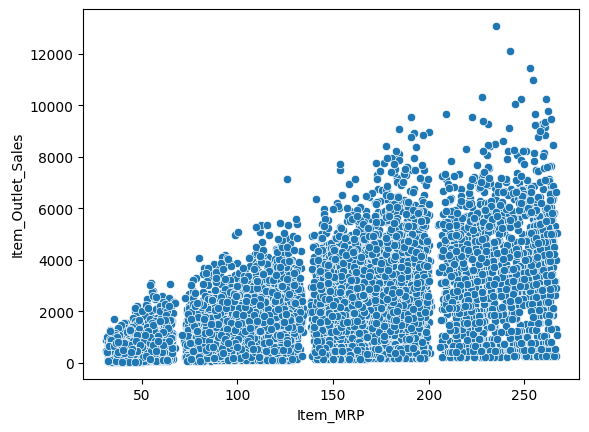

In [163]:
sns.scatterplot(x='Item_MRP',y='Item_Outlet_Sales', data=data)

In [164]:
data['Item_MRP_cat'] = pd.cut(data.Item_MRP, bins=[31,69,137,203,270], labels=['cat1','cat2','cat3','cat4'])

In [165]:
data.groupby(['Item_Type_Combined', 'Item_Type_New', 'Item_Type'])['Item_Outlet_Sales'].sum()

Item_Type_Combined  Item_Type_New   Item_Type            
Drinks              Non-Perishable  Hard Drinks              457793.42720
                                    Soft Drinks              892897.72200
                    Perishable      Dairy                    245178.18680
Food                Non-Perishable  Baking Goods            1265525.34220
                                    Canned                  1444151.49260
                                    Frozen Foods            1825734.78860
                    Perishable      Breads                   553237.18880
                                    Breakfast                232298.95160
                                    Dairy                   1277415.86440
                                    Fruits and Vegetables   2820059.81680
                                    Meat                     917565.61200
                                    Seafood                  148868.21940
                                    Snack Foods             2732786.08700
                                    Starchy Foods            351401.25040
Non_Consumable      Non-Perishable  Health and Hygiene      1045200.13780
                                    Household               2055493.71320
                    Unknown         Others                   325517.60960
Name: Item_Outlet_Sales, dtype: float64

In [166]:
data['MRP_per_unit_weight'] = data.Item_MRP/data.Item_Weight

In [167]:
data['Outlet_Years'] = 2025 - data['Outlet_Establishment_Year']

In [168]:
data['Outlet_Establishment_Year'] = data['Outlet_Establishment_Year'].astype('category')

In [169]:
data['Item_Identifier'] = data['Item_Identifier'].apply(lambda x: x[3:5])

In [170]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_visiblity_avg,Item_Type_Combined,Item_Type_New,Item_MRP_cat,MRP_per_unit_weight,Outlet_Years
0,15,9.30000,Low Fat,0.01605,Dairy,249.80920,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.13800,0.93108,Food,Perishable,cat4,26.86120,26
1,01,5.92000,Regular,0.01928,Soft Drinks,48.26920,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.42280,0.93342,Drinks,Non-Perishable,cat1,8.15358,16
2,15,17.50000,Low Fat,0.01676,Meat,141.61800,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.27000,0.96007,Food,Perishable,cat3,8.09246,26
3,07,19.20000,Regular,0.00000,Fruits and Vegetables,182.09500,OUT010,1998,Small,Tier 3,Grocery Store,732.38000,0.00000,Food,Perishable,cat3,9.48411,27
4,19,8.93000,Low Fat,0.00000,Household,53.86140,OUT013,1987,High,Tier 3,Supermarket Type1,994.70520,0.00000,Non_Consumable,Non-Perishable,cat1,6.03151,38


In [171]:
data['Item_visiblity_avg'] = np.log(data['Item_visiblity_avg'] + 1)

In [172]:
df = data.copy()

# One Hot Encoding

In [173]:
df_train = df.iloc[0:train.shape[0]]
df_test = df.iloc[train.shape[0]:]

In [174]:
print(df_train.shape,df_test.shape)

(8523, 18) (5681, 18)


Now we will do predict our data with get_dummies

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Identifier            14204 non-null  object  
 1   Item_Weight                14204 non-null  float64 
 2   Item_Fat_Content           14204 non-null  object  
 3   Item_Visibility            14204 non-null  float64 
 4   Item_Type                  14204 non-null  object  
 5   Item_MRP                   14204 non-null  float64 
 6   Outlet_Identifier          14204 non-null  object  
 7   Outlet_Establishment_Year  14204 non-null  category
 8   Outlet_Size                14204 non-null  object  
 9   Outlet_Location_Type       14204 non-null  object  
 10  Outlet_Type                14204 non-null  object  
 11  Item_Outlet_Sales          8523 non-null   float64 
 12  Item_visiblity_avg         14204 non-null  float64 
 13  Item_Type_Combined         1420

In [176]:
df_train.select_dtypes(include='float').columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales',
       'Item_visiblity_avg', 'MRP_per_unit_weight'],
      dtype='object')

In [177]:
df_train = pd.get_dummies(df_train)

In [178]:
df_train.corr()['Item_Outlet_Sales']

,Item_Outlet_Sales
Item_Weight,0.01108
Item_Visibility,-0.12862
Item_MRP,0.56757
Item_Outlet_Sales,1.00000
Item_visiblity_avg,-0.18884
MRP_per_unit_weight,0.39138
Outlet_Years,0.04913
Item_Identifier_01,-0.00564
Item_Identifier_02,0.00736
Item_Identifier_03,0.00040


In [179]:
df_train.head()

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Item_visiblity_avg,MRP_per_unit_weight,Outlet_Years,Item_Identifier_01,Item_Identifier_02,Item_Identifier_03,Item_Identifier_04,Item_Identifier_05,Item_Identifier_06,Item_Identifier_07,Item_Identifier_08,Item_Identifier_09,Item_Identifier_10,Item_Identifier_11,Item_Identifier_12,Item_Identifier_13,Item_Identifier_14,Item_Identifier_15,Item_Identifier_16,Item_Identifier_17,Item_Identifier_18,Item_Identifier_19,Item_Identifier_20,Item_Identifier_21,Item_Identifier_22,Item_Identifier_23,Item_Identifier_24,Item_Identifier_25,Item_Identifier_26,Item_Identifier_27,Item_Identifier_28,Item_Identifier_29,Item_Identifier_30,Item_Identifier_31,Item_Identifier_32,Item_Identifier_33,Item_Identifier_34,Item_Identifier_35,Item_Identifier_36,Item_Identifier_37,Item_Identifier_38,Item_Identifier_39,Item_Identifier_40,Item_Identifier_41,Item_Identifier_42,Item_Identifier_43,Item_Identifier_44,Item_Identifier_45,Item_Identifier_46,Item_Identifier_47,Item_Identifier_48,Item_Identifier_49,Item_Identifier_50,Item_Identifier_51,Item_Identifier_52,Item_Identifier_53,Item_Identifier_54,Item_Identifier_55,Item_Identifier_56,Item_Identifier_57,Item_Identifier_58,Item_Identifier_59,Item_Identifier_60,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Establishment_Year_1985,Outlet_Establishment_Year_1987,Outlet_Establishment_Year_1997,Outlet_Establishment_Year_1998,Outlet_Establishment_Year_1999,Outlet_Establishment_Year_2002,Outlet_Establishment_Year_2004,Outlet_Establishment_Year_2007,Outlet_Establishment_Year_2009,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Type_Combined_Drinks,Item_Type_Combined_Food,Item_Type_Combined_Non_Consumable,Item_Type_New_Non-Perishable,Item_Type_New_Perishable,Item_Type_New_Unknown,Item_MRP_cat_cat1,Item_MRP_cat_cat2,Item_MRP_cat_cat3,Item_MRP_cat_cat4
0,9.30000,0.01605,249.80920,3735.13800,0.65808,26.86120,26,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True
1,5.92000,0.01928,48.26920,443.42280,0.65929,8.15358,16,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,Fa

In [180]:
df_train.shape

(8523, 124)

In [181]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Columns: 124 entries, Item_Weight to Item_MRP_cat_cat4
dtypes: bool(117), float64(6), int64(1)
memory usage: 1.4 MB


In [182]:
df_x = df_train.drop(['Item_Outlet_Sales'], axis=1)
df_y = df_train['Item_Outlet_Sales']

In [183]:
x_train, x_test, y_train, y_test=train_test_split(df_x,df_y, train_size=0.8, random_state=10)

# Modeling

In [184]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=400, bootstrap=True, min_samples_leaf=100, min_samples_split=8, max_depth=6)
ada = AdaBoostRegressor(n_estimators=1000, learning_rate=0.01)
gbr = GradientBoostingRegressor(learning_rate=0.01, n_estimators=1000, max_depth=5, min_samples_split=8, min_samples_leaf=100)
xgb = XGBRegressor(n_jobs=-1, n_estimators=1000, max_depth=5)
cat = CatBoostRegressor(verbose=0)
dtr = DecisionTreeRegressor(max_depth=15, min_samples_leaf=100)
lgbr = LGBMRegressor(n_estimators = 440, learning_rate=0.01, max_depth=12, objective='tweedie', num_leaves=15, num_threads = 4)
knn = KNeighborsRegressor()
mlp = MLPRegressor()
svr = SVR(kernel='linear', C=10, gamma='scale')

In [185]:
# -----------------------------
# Define Performance Containers
# -----------------------------
r2 = {}
rmse = {}
explained_variance = {}

# -----------------------------
# Define Model Evaluation Function
# -----------------------------
def model_train_perf(model, model_name):
    print(f"\n Training: {model_name}")
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    r2_score = metrics.r2_score(y_test, pred) * 100
    rmse_val = np.sqrt(metrics.mean_squared_error(y_test, pred))
    var = metrics.explained_variance_score(y_test, pred)

    # Save metrics
    r2[model_name] = r2_score
    rmse[model_name] = rmse_val
    explained_variance[model_name] = var


    # Print summary
    print(f"R2 Score: {r2_score:.2f}")
    print(f"RMSE: {rmse_val:.4f}")
    print(f"Explained Variance: {var:.4f}")


In [186]:
# Dictionary of models
models = {
    "Cat Boost": cat,
    "SVM": svr,
    "Multiple Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "AdaBoost": ada,
    "GBM": gbr,
    "Decision Tree": dtr,
    "Multi-layer Perceptron": mlp,
    "KNN": knn,
    "LightGBM": lgbr
}

# Train and evaluate all models
for name, model in models.items():
    model_train_perf(model, name)



 Training: Cat Boost
R2 Score: 57.62
RMSE: 1121.6555
Explained Variance: 0.5762

 Training: SVM
R2 Score: 55.75
RMSE: 1146.0803
Explained Variance: 0.5636

 Training: Multiple Linear Regression
R2 Score: 57.32
RMSE: 1125.6070
Explained Variance: 0.5732

 Training: Random Forest
R2 Score: 60.38
RMSE: 1084.4631
Explained Variance: 0.6041

 Training: XGBoost
R2 Score: 41.61
RMSE: 1316.5075
Explained Variance: 0.4165

 Training: AdaBoost
R2 Score: 57.40
RMSE: 1124.5688
Explained Variance: 0.5891

 Training: GBM
R2 Score: 60.94
RMSE: 1076.7457
Explained Variance: 0.6096

 Training: Decision Tree
R2 Score: 59.46
RMSE: 1096.9773
Explained Variance: 0.5949

 Training: Multi-layer Perceptron


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


R2 Score: 58.75
RMSE: 1106.6095
Explained Variance: 0.5876

 Training: KNN
R2 Score: 48.02
RMSE: 1242.1490
Explained Variance: 0.4814

 Training: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1492
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 123
[LightGBM] [Info] Start training from score 7.684916
R2 Score: 60.89
RMSE: 1077.4928
Explained Variance: 0.6089


In [187]:
import pandas as pd

results_df = pd.DataFrame({
    'R2 Score (%)': r2,
    'RMSE': rmse,
    'Explained Variance': explained_variance,
}).T

print("\n Model Evaluation Summary:")
display(results_df.round(4))


 Model Evaluation Summary:


,Cat Boost,SVM,Multiple Linear Regression,Random Forest,XGBoost,AdaBoost,GBM,Decision Tree,Multi-layer Perceptron,KNN,LightGBM
R2 Score (%),57.61670,55.75070,57.31750,60.38080,41.61210,57.39620,60.94270,59.46120,58.74610,48.02160,60.88850
RMSE,1121.65550,1146.08030,1125.60700,1084.46310,1316.50750,1124.56880,1076.74570,1096.97730,1106.60950,1242.14900,1077.49280
Explained Variance,0.57620,0.56360,0.57320,0.60410,0.41650,0.58910,0.60960,0.59490,0.58760,0.48140,0.60890


## Preparing Test Dataset

In [188]:
df_test.drop(['Item_Outlet_Sales'], axis=1, inplace=True)
df_test.reset_index(drop=True, inplace=True)
print(df_test.shape)
df_test_ = pd.get_dummies(df_test)
df_test_.reset_index(drop=True, inplace=True)
print(df_test.head())

(5681, 17)
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility    Item_Type  \
0              58     20.75000          Low Fat          0.00756  Snack Foods   
1              14      8.30000          Regular          0.03843        Dairy   
2              55     14.60000          Low Fat          0.09957       Others   
3              58      7.31500          Low Fat          0.01539  Snack Foods   
4              38     12.79285          Regular          0.11860        Dairy   

   Item_MRP Outlet_Identifier Outlet_Establishment_Year Outlet_Size  \
0 107.86220            OUT049                      1999      Medium   
1  87.31980            OUT017                      2007        High   
2 241.75380            OUT010                      1998       Small   
3 155.03400            OUT017                      2007        High   
4 234.23000            OUT027                      1985        High   

  Outlet_Location_Type        Outlet_Type  Item_visiblity_avg  \
0         

<ipython-input-188-07d8e81e6398>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['Item_Outlet_Sales'], axis=1, inplace=True)


# Lets Do HyperParameter Tuning

We are using GBM as final model because the error is minimum and r2 is maximum

##LightGBM

In [189]:
# # Stratify for regression
# y_bins = pd.qcut(df_y, q=10, labels=False)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Define LightGBM parameter grid
# lgbm_params = {
#     'n_estimators': [100, 200, 300, 400],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [5, 7, 10, -1],
#     'num_leaves': [20, 31, 40, 50],
#     'min_child_samples': [5, 10, 20],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'reg_alpha': [0, 0.1, 1.0],
#     'reg_lambda': [0, 0.1, 1.0]
# }

In [190]:
# lgbm = LGBMRegressor(random_state=42)

# lgbm_search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=lgbm_params,
#     scoring='neg_root_mean_squared_error',
#     n_iter=25,
#     cv=cv,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# # Fit on binned data for stratified CV
# lgbm_search.fit(df_x, y_bins)

# # Get the best model
# best_lgbm = lgbm_search.best_estimator_

# # Train on full data using real targets
# best_lgbm.fit(df_x, df_y)

# # Predict
# lgbm_preds = best_lgbm.predict(df_test_)

# # Clip negative predictions
# lgbm_preds = np.clip(lgbm_preds, 0, None)

# print(f"✅ Tuned LightGBM RMSE (CV estimate): {-lgbm_search.best_score_:.4f}")


In [191]:
# submission['Item_Outlet_Sales'] = lgbm_preds
# submission.to_csv('BigMart_LightGBM_Tuned.csv', index=False)
# print("✅ LightGBM tuned predictions saved to 'BigMart_LightGBM_Tuned.csv'")

#XGBOOST

In [192]:
# xgb = XGBRegressor()
# n_estimators = [int(x) for x in np.linspace(start=100, stop=1200, num=12)]
# max_depth = [int(x) for x in np.linspace(5, 30, num=6)]
# learning_rate = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
# min_child_weight = [3, 4, 5, 6, 7]
# subsample = [0.7, 0.6, 0.8]
# colsample_bytree = [0.7, 0.6, 0.8]
# reg_alpha = [0.01, 0.1, 1, 0.001, 0.0001]
# reg_lambda = [0.01, 0.1, 1, 0.001, 0.0001]

# # Create the random grid
# random_grid = {'n_estimators': n_estimators,
#                'max_depth': max_depth,
#                'learning_rate': learning_rate,
#                'min_child_weight': min_child_weight,
#                'subsample': subsample,
#                'colsample_bytree': colsample_bytree,
#                'reg_alpha': reg_alpha,
#                'reg_lambda': reg_lambda}
# # Random search of parameters, using 3 fold cross validation,
# # search across 100 different combinations
# xgb_random = RandomizedSearchCV(estimator=xgb, param_distributions=random_grid, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
# xgb_random.fit(x, y)

# # best parameters
# xgb_random.best_params_

In [193]:
# xgb_model = XGBRegressor(subsample=0.8, reg_lambda=0.01, reg_alpha=0.001, n_estimators=100, min_child_weight=6, max_depth=5, learning_rate=0.05, colsample_bytree=0.7)

In [194]:
# xgb_model.fit(df_x, df_y)
# train_preds = xgb_model.predict(df_x)
# rmse = np.sqrt(mean_squared_error(df_y, train_preds))
# print(f"Training RMSE (XGBoost): {rmse:.4f}")

In [195]:
# xgb_test_preds = xgb_model.predict(df_test_)
# submission = pd.read_csv('sample_submission_8RXa3c6.csv')
# submission['Item_Outlet_Sales'] = xgb_test_preds
# # submission.to_csv('BigMart_sales_predictions_XGB.csv', index=False)

#RandomForest

In [196]:
# # Define hyperparameter grid
# param_dist = {
#     'n_estimators': [50, 100, 150, 200, 300, 500],
#     'max_depth': [3,4,5, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# }

# # Stratified K-Fold based on binned y
# y_bins = pd.qcut(df_y, q=10, labels=False)
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Initialize model
# rf = RandomForestRegressor(random_state=42)

# # Randomized Search CV
# rs = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=20,
#     cv=cv,
#     scoring='neg_root_mean_squared_error',
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# # Fit the model
# rs.fit(df_x, y_bins)  # Use binned target for stratification

# # Best estimator
# best_rf = rs.best_estimator_

# # -----------------------
# # Final Training & Prediction
# # -----------------------

# best_rf.fit(df_x, df_y)
# train_preds = best_rf.predict(df_x)
# rmse = np.sqrt(mean_squared_error(df_y, train_preds))
# print(f"Training RMSE (with tuned RF): {rmse:.4f}")

In [197]:
# final_test_preds = best_rf.predict(df_test_)
# submission = pd.read_csv('sample_submission_8RXa3c6.csv')
# submission['Item_Outlet_Sales'] = final_test_preds
# submission.to_csv('BigMart_sales_predictions_RF.csv', index=False)

# GBM

In [198]:
# Stratified K-Fold on binned y
y_bins = pd.qcut(df_y, q=10, labels=False)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define hyperparameter space
gbm_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': np.linspace(0.09, 0.11, 10),
    'max_depth': [2,3, 4, 5, 6],
    'min_samples_split': [9, 10, 11, 12],
    'min_samples_leaf': [4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}


In [199]:
gbm = GradientBoostingRegressor(random_state=42)

gbm_search = RandomizedSearchCV(
    estimator=gbm,
    param_distributions=gbm_params,
    scoring='neg_root_mean_squared_error',
    n_iter=25,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit using binned targets for stratification
gbm_search.fit(df_x, y_bins)

# Best estimator
best_gbm = gbm_search.best_estimator_

# Train final model on true y
best_gbm.fit(df_x, df_y)

# Predict on test set
gbm_preds = best_gbm.predict(df_test_)
gbm_preds = np.clip(gbm_preds, 0, None)

print(f"✅ Tuned GBM RMSE (CV estimate): {-gbm_search.best_score_:.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
✅ Tuned GBM RMSE (CV estimate): 1.6539


In [200]:
gbm_search.best_estimator_

GradientBoostingRegressor(learning_rate=np.float64(0.09), max_depth=2,
                          min_samples_leaf=5, min_samples_split=11,
                          n_estimators=200, random_state=42)

In [201]:
print("Learning rate:", best_gbm.learning_rate)
print("Max depth:", best_gbm.max_depth)
print("n_estimators:", best_gbm.n_estimators)

Learning rate: 0.09
Max depth: 2
n_estimators: 200


In [202]:
submission = pd.read_csv('sample_submission_8RXa3c6.csv')
submission['Item_Outlet_Sales'] = gbm_preds
submission.to_csv('gbm.csv', index=False)